Shape: (500, 9)
                     Order Date         Category Sub-Category Region  \
0 2022-01-01 00:00:00.000000000       Technology  Accessories  North   
1 2022-01-02 11:03:43.647294589  Office Supplies      Storage   West   
2 2022-01-03 22:07:27.294589178  Office Supplies      Binders   West   
3 2022-01-05 09:11:10.941883767       Technology       Phones  North   
4 2022-01-06 20:14:54.589178356        Furniture       Chairs  North   

  Product Name    Sales  Profit  Year  Month  
0  Product_065   533.24   68.53  2022      1  
1  Product_017   409.39   50.80  2022      1  
2  Product_022    69.23   22.28  2022      1  
3  Product_041  1518.00  189.54  2022      1  
4  Product_068   335.15   44.10  2022      1  

Missing Values: 0


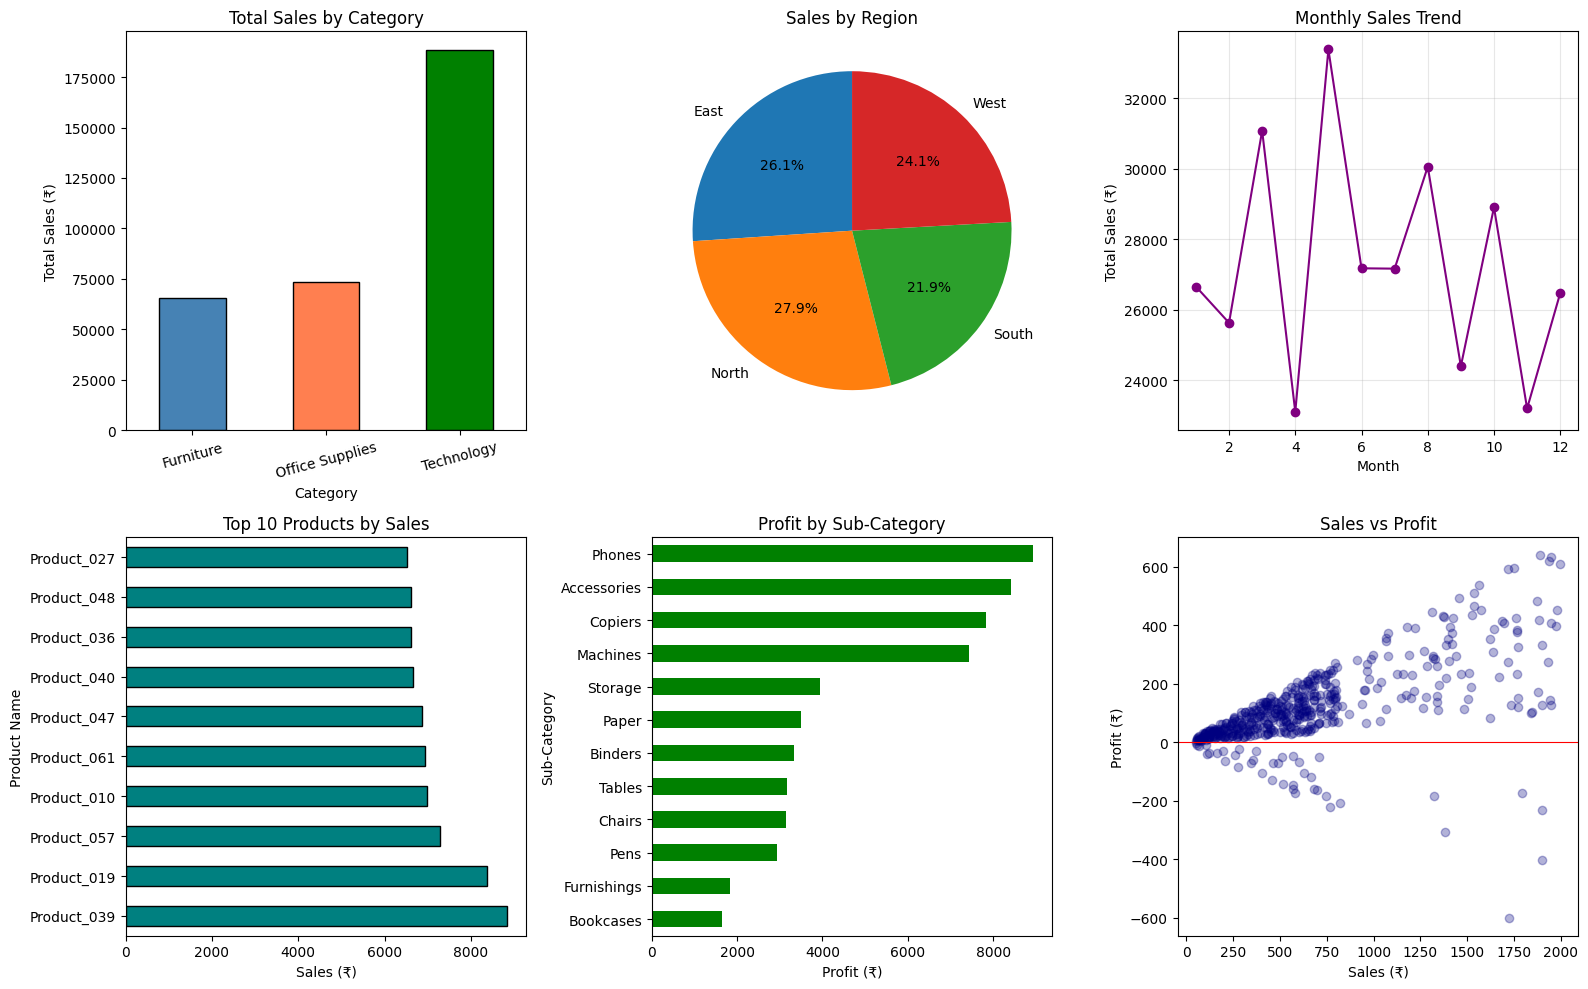


=== SALES SUMMARY ===
Total Revenue : ₹327,221.80
Total Profit  : ₹56,105.25
Profit Margin : 17.15%
Best Category : Technology
Best Region   : North
Loss-making sub-categories:
Series([], Name: Profit, dtype: float64)


In [1]:
# ============================================
# PROJECT 2: Sales Data Analysis
# SPPU Data Science Lab - PCC-255-CAI
# Dataset: Generated in-code (no download)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 500

categories    = ['Furniture', 'Technology', 'Office Supplies']
subcategories = {
    'Furniture':        ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Technology':       ['Phones', 'Accessories', 'Machines', 'Copiers'],
    'Office Supplies':  ['Binders', 'Paper', 'Storage', 'Pens']
}
regions    = ['East', 'West', 'North', 'South']
cat_list   = np.random.choice(categories, n, p=[0.3, 0.35, 0.35])
sub_list   = [np.random.choice(subcategories[c]) for c in cat_list]
region_list= np.random.choice(regions, n)

dates = pd.date_range('2022-01-01', '2023-12-31', periods=n)
sales  = np.where(cat_list=='Technology',
                  np.random.uniform(200, 2000, n),
                  np.random.uniform(50, 800, n)).round(2)
profit = (sales * np.random.uniform(0.05, 0.35, n)).round(2)
profit[np.random.choice(n, 40, replace=False)] *= -1   # some losses

products = [f"Product_{i:03d}" for i in np.random.randint(1, 80, n)]

df = pd.DataFrame({
    'Order Date':   dates,
    'Category':     cat_list,
    'Sub-Category': sub_list,
    'Region':       region_list,
    'Product Name': products,
    'Sales':        sales,
    'Profit':       profit,
})
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("Shape:", df.shape)
print(df.head())
print("\nMissing Values:", df.isnull().sum().sum())

# --- Visualizations ---
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
df.groupby('Category')['Sales'].sum().plot(
    kind='bar', color=['steelblue','coral','green'], edgecolor='black')
plt.title('Total Sales by Category')
plt.xlabel('Category'); plt.ylabel('Total Sales (₹)'); plt.xticks(rotation=15)

plt.subplot(2, 3, 2)
df.groupby('Region')['Sales'].sum().plot(
    kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales by Region'); plt.ylabel('')

plt.subplot(2, 3, 3)
df.groupby('Month')['Sales'].sum().plot(
    kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trend')
plt.xlabel('Month'); plt.ylabel('Total Sales (₹)'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
top10 = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top10.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Products by Sales'); plt.xlabel('Sales (₹)')

plt.subplot(2, 3, 5)
prof = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in prof]
prof.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category'); plt.xlabel('Profit (₹)')

plt.subplot(2, 3, 6)
plt.scatter(df['Sales'], df['Profit'], alpha=0.3, color='navy')
plt.title('Sales vs Profit')
plt.xlabel('Sales (₹)'); plt.ylabel('Profit (₹)')
plt.axhline(0, color='red', linewidth=0.8)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=100)
plt.show()

print("\n=== SALES SUMMARY ===")
print(f"Total Revenue : ₹{df['Sales'].sum():,.2f}")
print(f"Total Profit  : ₹{df['Profit'].sum():,.2f}")
print(f"Profit Margin : {df['Profit'].sum()/df['Sales'].sum()*100:.2f}%")
print(f"Best Category : {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Best Region   : {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Loss-making sub-categories:")
loss = df.groupby('Sub-Category')['Profit'].sum()
print(loss[loss < 0].sort_values())